# DL Midterm Project: BraTS 2D Binary Baseline

This notebook is the learning/inspection layer.
- Check environment and paths
- Load one BraTS case from `BraTS2021_00495.tar`
- Visualize MRI + tumor mask slices
- Build 2D binary slices (`X`, `y`) for training

Production training code lives in Python scripts: `data.py`, `dataset.py`, `model.py`, `losses.py`, `eval.py`, `train.py`.


In [15]:
import sys, os, subprocess
from pathlib import Path

# --- Environment setup (works everywhere: Colab, VSCode, terminal) ---
PROJECT_DIR = Path(".")

# Files needed for the notebook
FILES = {
    "BraTS2021_00495.tar": "1hgZSAx6vCjqFb11eXM5euLzO5X5XFVER",
    "data.py":             "1qJJy-_HTutMqZmo6KPUaX06T-MzMlaHu",
    "dataset.py":          "1dFwfGbYXk_YQ-BPRn-3f3TMDOXXDonXm",
    "model.py":            "1RK32QQvz_DDZbSlToSZ6XRpq4n2chgpf",
    "losses.py":           "11Q93wDfxTyGvkbPJ-L_ZK4Z5n15r6sA9",
    "eval.py":             "1jQyyqvwDr0WlOVagMdIE3e-AypDNV5Vs",
}
RUN_FILES = {
    "runs/baseline_2d_e20/history.json": "1_y5JOK-qb5DRLgvs44xMdGSZvVyqDa-4",
    "runs/baseline_2d_e20/best.pt":      "1L8CC6FaWO4PNOcocEkxlVgwJZWP6Toz8",
}

# Check if any files are missing
missing = [f for f in {**FILES, **RUN_FILES} if not Path(f).exists()]

if missing:
    print(f"Downloading {len(missing)} missing file(s)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown", "nibabel"])
    import gdown

    os.makedirs("runs/baseline_2d_e20", exist_ok=True)
    all_files = {**FILES, **RUN_FILES}
    for fname in missing:
        gdown.download(id=all_files[fname], output=fname, quiet=True)
        print(f"  Downloaded {fname}")
    print("All files ready.")
else:
    print("All files already present.")

print('Python:', sys.executable)
print('Working dir:', Path.cwd())


In [16]:
# Run only if packages are missing in your .venv kernel
# %pip install nibabel numpy matplotlib torch


In [17]:
import numpy as np
import matplotlib.pyplot as plt

from data import load_case_volumes, normalize_modalities, to_binary_mask, find_tumor_slices, build_slices
from dataset import make_loaders
from model import UNet2D
from losses import DiceBCELoss


In [18]:
case_path = PROJECT_DIR / "BraTS2021_00495.tar"
assert case_path.exists(), f'Missing file: {case_path.resolve()}'
print('Case source:', case_path.resolve())


In [19]:
volumes = load_case_volumes(case_path)
for k, v in volumes.items():
    print(f'{k}: shape={v.shape}, dtype={v.dtype}')

print('Original mask labels:', np.unique(volumes['seg']))


t1: shape=(240, 240, 155), dtype=float32
t1ce: shape=(240, 240, 155), dtype=float32
t2: shape=(240, 240, 155), dtype=float32
flair: shape=(240, 240, 155), dtype=float32
seg: shape=(240, 240, 155), dtype=float32
Original mask labels: [0. 1. 2. 4.]


In [20]:
volumes = normalize_modalities(volumes)
binary_seg = to_binary_mask(volumes['seg'])
tumor_slices = find_tumor_slices(binary_seg)

print('Binary mask values:', np.unique(binary_seg))
print('Tumor-positive slices:', len(tumor_slices))
print('First 10 tumor slices:', tumor_slices[:10])


Binary mask values: [0. 1.]
Tumor-positive slices: 70
First 10 tumor slices: [66, 67, 68, 69, 70, 71, 72, 73, 74, 75]


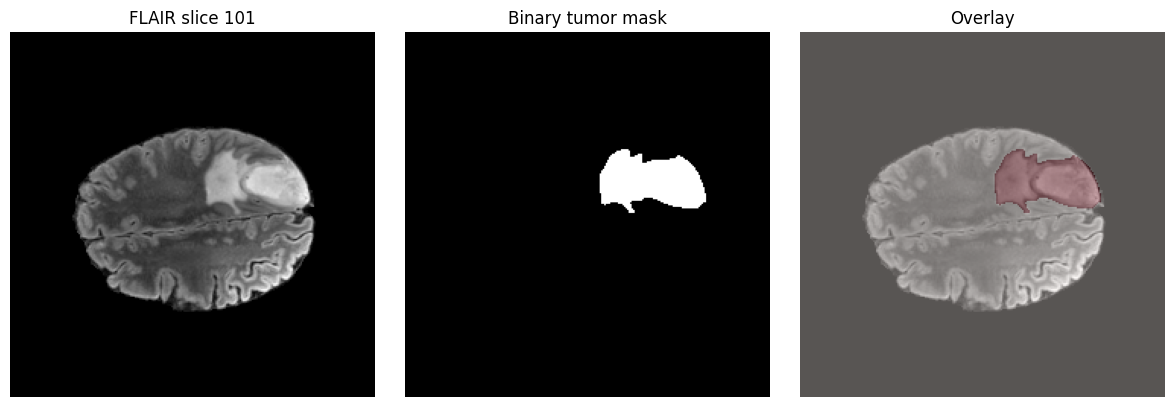

In [21]:
slice_idx = tumor_slices[len(tumor_slices) // 2]

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(volumes['flair'][:, :, slice_idx], cmap='gray')
plt.title(f'FLAIR slice {slice_idx}')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary_seg[:, :, slice_idx], cmap='gray')
plt.title('Binary tumor mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(volumes['flair'][:, :, slice_idx], cmap='gray')
plt.imshow(binary_seg[:, :, slice_idx], cmap='Reds', alpha=0.35)
plt.title('Overlay')
plt.axis('off')

plt.tight_layout()
plt.show()


In [22]:
X, y, used_indices = build_slices(volumes, only_tumor=True, return_indices=True)
print('X shape:', X.shape, 'dtype:', X.dtype)
print('y shape:', y.shape, 'dtype:', y.dtype)
print('y unique values:', np.unique(y))

# Contract checks
assert X.dtype == np.float32 and y.dtype == np.float32
assert X.ndim == 4 and y.ndim == 4
assert X.shape[1] == 4 and y.shape[1] == 1
assert set(np.unique(y).tolist()).issubset({0.0, 1.0})


X shape: (70, 4, 240, 240) dtype: float32
y shape: (70, 1, 240, 240) dtype: float32
y unique values: [0. 1.]


In [23]:
train_loader, val_loader = make_loaders(X, y, batch_size=4, val_ratio=0.2, seed=42)

xb, yb = next(iter(train_loader))
print('One train batch:', xb.shape, yb.shape, xb.dtype, yb.dtype)
print('Val loader is None?', val_loader is None)


One train batch: torch.Size([4, 4, 240, 240]) torch.Size([4, 1, 240, 240]) torch.float32 torch.float32
Val loader is None? False


In [24]:
import torch

model = UNet2D(in_channels=4, out_channels=1, base_channels=16)
criterion = DiceBCELoss(dice_weight=0.5, bce_weight=0.5)

logits = model(xb)
loss = criterion(logits, yb)
print('Forward pass OK. logits:', logits.shape, 'loss:', float(loss.item()))


Forward pass OK. logits: torch.Size([4, 1, 240, 240]) loss: 0.8583403825759888


## Next step (from terminal)

Single-case check with early stopping:
`python train.py --epochs 50 --batch-size 4 --cpu --case-path BraTS2021_00495.tar --early-stopping-patience 5 --early-stopping-min-delta 0.001 --output-dir runs/single_es`

Multi-case run (patient-level split) after you place several `.tar` files in one folder:
`python train.py --epochs 50 --batch-size 4 --cpu --case-path /path/to/brats_cases_dir --val-ratio 0.2 --max-cases 10 --early-stopping-patience 8 --early-stopping-min-delta 0.001 --output-dir runs/multicase_es`

Artifacts are saved in `runs/...` as `best.pt`, `latest.pt`, `history.json`.


## Stage D — Evaluation and Baseline Results

Load `history.json` from a completed training run, plot training curves, then evaluate the best checkpoint on the validation loader.

**Expected run:** `runs/baseline_2d_e20` — 20-epoch single-case run, best val Dice ≈ 0.9751 (epoch 17).
Change `run_dir` below to any other run if needed.

Epochs trained  : 20
Best val Dice   : 0.9751  (epoch 17)
Final val Dice  : 0.8063
Train loss      : 0.7046 → 0.2031


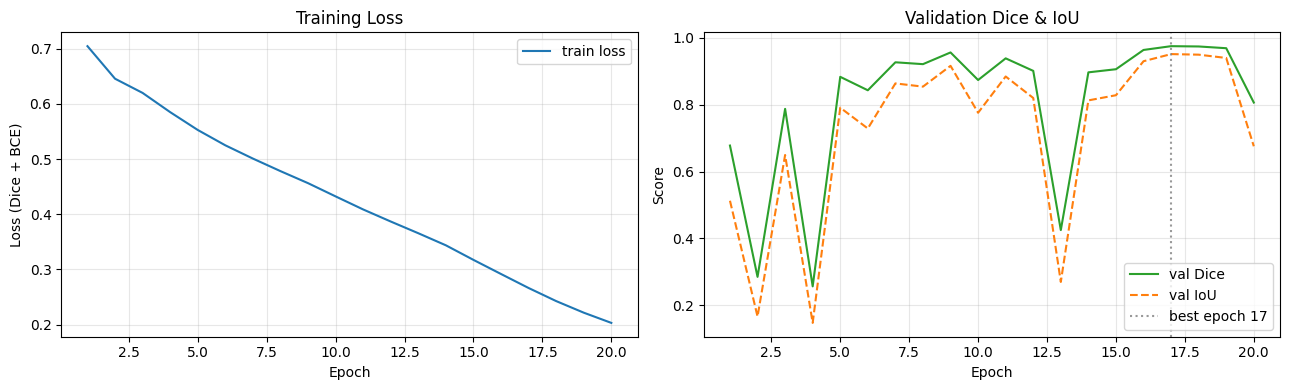

In [25]:
import json

run_dir = PROJECT_DIR / "runs/baseline_2d_e20"   # ← change to your run
history_path = run_dir / 'history.json'
assert history_path.exists(), f'history.json not found in {run_dir.resolve()}'

with open(history_path) as f:
    history = json.load(f)

epochs     = list(range(1, len(history['train_loss']) + 1))
train_loss = history['train_loss']
val_dice   = history['val_dice']
val_iou    = history['val_iou']

best_epoch = epochs[val_dice.index(max(val_dice))]
print(f'Epochs trained  : {len(epochs)}')
print(f'Best val Dice   : {max(val_dice):.4f}  (epoch {best_epoch})')
print(f'Final val Dice  : {val_dice[-1]:.4f}')
print(f'Train loss      : {train_loss[0]:.4f} → {train_loss[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs, train_loss, color='tab:blue', label='train loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (Dice + BCE)')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, val_dice, color='tab:green', label='val Dice')
ax2.plot(epochs, val_iou,  color='tab:orange', label='val IoU', linestyle='--')
ax2.axvline(best_epoch, linestyle=':', color='gray', alpha=0.8, label=f'best epoch {best_epoch}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.set_title('Validation Dice & IoU')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import torch
from eval import evaluate

device = 'cpu'
checkpoint_path = run_dir / 'best.pt'
assert checkpoint_path.exists(), f'best.pt not found in {run_dir.resolve()}'

state = torch.load(checkpoint_path, map_location=device)
model_eval = UNet2D(in_channels=4, out_channels=1, base_channels=16)
model_eval.load_state_dict(state['model_state_dict'])
model_eval.eval()

print(f'Checkpoint from  : epoch {state["epoch"]}')
print(f'Saved best_dice  : {state["best_dice"]:.4f}')

# Evaluate on the same val_loader built above
metrics = evaluate(model_eval, val_loader, device=device)
print()
print('─' * 36)
print(f'  {"Metric":<14} {"Value":>8}')
print('─' * 36)
for name, val in metrics.items():
    print(f'  {name:<14} {val:>8.4f}')
print('─' * 36)

In [ ]:
# Visual comparison: FLAIR | Ground Truth | Prediction
# Run a forward pass on one validation batch

xb_vis, yb_vis = next(iter(val_loader))

with torch.no_grad():
    preds_vis = (torch.sigmoid(model_eval(xb_vis)) >= 0.5).float()

n_show = min(4, xb_vis.shape[0])
fig, axes = plt.subplots(n_show, 3, figsize=(11, 3 * n_show))

col_titles = ['FLAIR', 'Ground Truth', 'Prediction']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13, pad=8)

for i in range(n_show):
    flair = xb_vis[i, 3].numpy()   # channel index 3 = FLAIR
    gt    = yb_vis[i, 0].numpy()
    pred  = preds_vis[i, 0].numpy()

    dice_i = (2 * (pred * gt).sum() + 1e-6) / (pred.sum() + gt.sum() + 1e-6)

    axes[i, 0].imshow(flair, cmap='gray')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(flair, cmap='gray')
    axes[i, 1].imshow(gt, cmap='Reds', alpha=0.45)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(flair, cmap='gray')
    axes[i, 2].imshow(pred, cmap='Blues', alpha=0.45)
    axes[i, 2].set_xlabel(f'Dice = {dice_i:.3f}', fontsize=10)
    axes[i, 2].axis('off')

plt.suptitle('Validation slices — red: GT tumor, blue: predicted tumor', y=1.01)
plt.tight_layout()
plt.show()

## Stage E — Next Steps (multi-case)

All of the above ran on **one BraTS case**. For true generalization we need patient-level train/val split across multiple patients.

### When you have more cases

Place several `BraTS*.tar` files into a single folder, then run from terminal:

```bash
python train.py \
  --epochs 50 --batch-size 4 --cpu \
  --case-path /path/to/brats_cases_dir \
  --val-ratio 0.2 --max-cases 10 \
  --early-stopping-patience 8 --early-stopping-min-delta 0.001 \
  --output-dir runs/multicase_es
```

Then re-run the Stage D cells above with `run_dir = Path('runs/multicase_es')`.

### After stable multi-case baseline
- **Multiclass segmentation** — output `out_channels=3` (necrotic / edema / enhancing); use CrossEntropyLoss.
- **3D pipeline** — volumetric U-Net on full 240×240×155 volumes with patch sampling.
- **Optuna tuning** — sweep LR, batch size, Dice/BCE weight ratio.
- **Uncertainty maps** — MC Dropout at inference to flag ambiguous voxels.